<a href="https://colab.research.google.com/github/TharinduLakshimal/robotic-hazard-detection/blob/30-epchos/Officail_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

DRIVE_BASE   = '/content/drive/MyDrive/GlassDetection_Official'
RUNS_DIR     = os.path.join(DRIVE_BASE, 'runs')
WEIGHTS_DIR  = os.path.join(DRIVE_BASE, 'weights')
DATASET_DIR  = os.path.join(DRIVE_BASE, 'datasets')

os.makedirs(DRIVE_BASE,  exist_ok=True)
os.makedirs(RUNS_DIR,    exist_ok=True)
os.makedirs(WEIGHTS_DIR, exist_ok=True)
os.makedirs(DATASET_DIR, exist_ok=True)

print('✅ Folders ready:', os.listdir(DRIVE_BASE))

Mounted at /content/drive
✅ Folders ready: ['runs', 'weights', 'datasets']


In [2]:
!pip install ultralytics roboflow --quiet

from ultralytics import YOLO
import torch

print('✅ YOLO ready')
print(f'GPU available: {torch.cuda.is_available()}')
print(f'GPU name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE — change runtime to T4"}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 86.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 57.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ YOLO ready
GPU available: True
GPU name: Tesla T4


In [3]:
from roboflow import Roboflow
import os

DRIVE_DATASET_PATH = '/content/drive/MyDrive/GlassDetection_Official/datasets'
os.makedirs(DRIVE_DATASET_PATH, exist_ok=True)
os.chdir(DRIVE_DATASET_PATH)

# --- REPLACE WITH YOUR DETAILS ---
rf = Roboflow(api_key="uwXX0JgH0syUfCz3yEa1")
project = rf.workspace("tharindus-workspace-b7nsk").project("vacuum-hazard-detection-v1")
version = project.version(2)
dataset = version.download("yolov8")

print(f'✅ Dataset downloaded to: {dataset.location}')

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Vacuum-Hazard-Detection-v1-2 in yolov8:: 100%|██████████| 8477/8477 [01:24<00:00, 100.54it/s]


✅ Dataset downloaded to: /content/drive/MyDrive/GlassDetection_Official/datasets/Vacuum-Hazard-Detection-v1-2


In [4]:
import yaml
import os

# Dataset base path
BASE = '/content/drive/MyDrive/GlassDetection_Official/datasets/Vacuum-Hazard-Detection-v1-2'

# Path to create/update data.yaml
yaml_path = os.path.join(BASE, 'data.yaml')

# Create new data.yaml
data = {
    'train': os.path.join(BASE, 'train/images'),
    'val': os.path.join(BASE, 'valid/images'),
    'test': os.path.join(BASE, 'test/images'),
    'nc': 1,
    'names': ['broken_glass']
}

# Write the YAML file
with open(yaml_path, 'w') as f:
    yaml.dump(data, f, sort_keys=False)

print("✅ data.yaml created successfully!")

# Display the contents
with open(yaml_path, 'r') as f:
    print(f.read())

✅ data.yaml created successfully!
train: /content/drive/MyDrive/GlassDetection_Official/datasets/Vacuum-Hazard-Detection-v1-2/train/images
val: /content/drive/MyDrive/GlassDetection_Official/datasets/Vacuum-Hazard-Detection-v1-2/valid/images
test: /content/drive/MyDrive/GlassDetection_Official/datasets/Vacuum-Hazard-Detection-v1-2/test/images
nc: 1
names:
- broken_glass



In [5]:
import os

BASE = '/content/drive/MyDrive/GlassDetection_Official/datasets/Vacuum-Hazard-Detection-v1-2'

for split in ['train', 'valid', 'test']:
    img_path = os.path.join(BASE, split, 'images')
    count = len(os.listdir(img_path)) if os.path.exists(img_path) else 0
    print(f'{split:10}: {count} images')

# Expected: train=3540  valid=306  test=390

train     : 3540 images
valid     : 306 images
test      : 390 images


In [6]:
import os

BASE = '/content/drive/MyDrive/GlassDetection_Official/datasets/Vacuum-Hazard-Detection-v1-2'

label_dirs = [
    os.path.join(BASE, 'train', 'labels'),
    os.path.join(BASE, 'valid', 'labels'),
    os.path.join(BASE, 'test',  'labels')
]

total_removed = 0

for label_dir in label_dirs:
    dir_removed = 0
    for filename in os.listdir(label_dir):
        if filename.endswith('.txt'):
            filepath = os.path.join(label_dir, filename)
            with open(filepath, 'r') as f:
                lines = f.readlines()
            valid_lines = []
            for line in lines:
                parts = line.strip().split()
                if len(parts) > 5:       # polygon = keep
                    valid_lines.append(line)
                else:
                    dir_removed += 1     # bounding box = remove
            with open(filepath, 'w') as f:
                f.writelines(valid_lines)
    total_removed += dir_removed
    print(f'✅ Cleaned {label_dir.split("/")[-2]:8} — removed {dir_removed} box annotations')

print(f'\n✅ Total removed: {total_removed}')
print('Dataset clean! Ready to train.')

✅ Cleaned train    — removed 3 box annotations
✅ Cleaned valid    — removed 0 box annotations
✅ Cleaned test     — removed 0 box annotations

✅ Total removed: 3
Dataset clean! Ready to train.


In [7]:
import glob, os

BASE = '/content/drive/MyDrive/GlassDetection_Official/datasets/Vacuum-Hazard-Detection-v1-2'

cache_files = glob.glob(BASE + '/**/*.cache', recursive=True)

for cache in cache_files:
    os.remove(cache)
    print(f'🗑️ Deleted: {cache}')

if not cache_files:
    print('✅ No cache files found (already clean)')
else:
    print('✅ All cache cleared. Ready to train.')

✅ No cache files found (already clean)


In [8]:
from ultralytics import YOLO
import os

RUNS_DIR  = '/content/drive/MyDrive/GlassDetection_Official/runs'
yaml_path = '/content/drive/MyDrive/GlassDetection_Official/datasets/Vacuum-Hazard-Detection-v1-2/data.yaml'

# Load pretrained YOLOv8 medium segmentation model
model = YOLO('yolov8m-seg.pt')

results = model.train(
    data         = yaml_path,
    epochs       = 30,
    imgsz        = 640,
    batch        = 16,        # reduce to 8 if CUDA out of memory error
    patience     = 20,        # early stop if no improvement for 20 epochs
    optimizer    = 'AdamW',
    lr0          = 0.001,
    weight_decay = 0.0005,
    augment      = False,     # already done in Roboflow
    project      = RUNS_DIR,
    name         = 'glass_seg_v1_30',
    save         = True,
    save_period  = 10,        # checkpoint saved to Drive every 10 epochs
    device       = 0,
    workers      = 2,
    plots        = True,
    verbose      = True
)

print('✅ Training Complete!')

Ultralytics 8.4.81 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/GlassDetection_Official/datasets/Vacuum-Hazard-Detection-v1-2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=glass_seg_v1_30, nbs=64, nms=F

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import os
print('✅ Drive mounted')

Mounted at /content/drive
✅ Drive mounted


In [3]:
!pip install ultralytics --quiet
import torch
print(f'GPU: {torch.cuda.get_device_name(0)}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 63.6 MB/s eta 0:00:00
GPU: Tesla T4


In [5]:
from google.colab import drive
drive.mount('/content/drive')

!pip install ultralytics --quiet

from ultralytics import YOLO
import torch, os

print(f'GPU: {torch.cuda.get_device_name(0)}')

DRIVE_BASE  = '/content/drive/MyDrive/GlassDetection_Official'
RUNS_DIR    = os.path.join(DRIVE_BASE, 'runs')
WEIGHTS_DIR = os.path.join(DRIVE_BASE, 'weights')
yaml_path   = os.path.join(DRIVE_BASE, 'datasets/Vacuum-Hazard-Detection-v1-2/data.yaml')

# Copy best weights
import shutil
RUN_NAME = 'glass_seg_v1_30'   # change to glass_seg_v1-2 if needed

best_src = os.path.join(RUNS_DIR, RUN_NAME, 'weights', 'best.pt')
shutil.copy(best_src, os.path.join(WEIGHTS_DIR, 'best_no_clahe.pt'))

print('✅ Best weights saved')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
GPU: Tesla T4
✅ Best weights saved


In [6]:
from ultralytics import YOLO

model = YOLO(os.path.join(WEIGHTS_DIR, 'best_no_clahe.pt'))

metrics_noclahe = model.val(
    data    = yaml_path,
    split   = 'test',
    imgsz   = 640,
    device  = 0,
    plots   = True,
    project = RUNS_DIR,
    name    = 'eval_no_clahe'
)

print('\n=== BASELINE (No CLAHE) Test Results ===')
print(f'Mask mAP@50    : {metrics_noclahe.seg.map50:.4f}')
print(f'Mask mAP@50-95 : {metrics_noclahe.seg.map:.4f}')
print(f'Box  mAP@50    : {metrics_noclahe.box.map50:.4f}')
print(f'Precision      : {metrics_noclahe.seg.mp:.4f}')
print(f'Recall         : {metrics_noclahe.seg.mr:.4f}')

# Save results for later comparison
no_clahe_results = {
    'mask_map50'   : round(metrics_noclahe.seg.map50, 4),
    'mask_map5095' : round(metrics_noclahe.seg.map,   4),
    'box_map50'    : round(metrics_noclahe.box.map50, 4),
    'precision'    : round(metrics_noclahe.seg.mp,    4),
    'recall'       : round(metrics_noclahe.seg.mr,    4)
}
print('\nSaved for comparison:', no_clahe_results)

Ultralytics 8.4.82 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8m-seg summary (fused): 106 layers, 27,222,963 parameters, 0 gradients, 104.3 GFLOPs
val: Fast image access ✅ (ping: 0.9±0.8 ms, read: 0.0±0.0 MB/s, size: 21.3 KB)
val: Scanning /content/drive/MyDrive/GlassDetection_Official/datasets/Vacuum-Hazard-Detection-v1-2/test/labels... 390 images, 142 backgrounds, 162 corrupt: 100% ━━━━━━━━━━━━ 390/390 2.2it/s 3:00
val: /content/drive/MyDrive/GlassDetection_Official/datasets/Vacuum-Hazard-Detection-v1-2/test/images/bg_brown_black_002_frame_00001_jpg.rf.c55fdde9fa9bc66b03742349031329f4.jpg: ignoring corrupt image/label: Label class 1 exceeds dataset class count 1. Possible class labels are 0-0
val: /content/drive/MyDrive/GlassDetection_Official/datasets/Vacuum-Hazard-Detection-v1-2/test/images/bg_brown_black_003_frame_00018_jpg.rf.cd6966a9695d7ee3d5b3a8992f48ba9d.jpg: ignoring corrupt image/label: Label class 1 exceeds dataset class count 1. Possible class la


📈 confusion_matrix.png


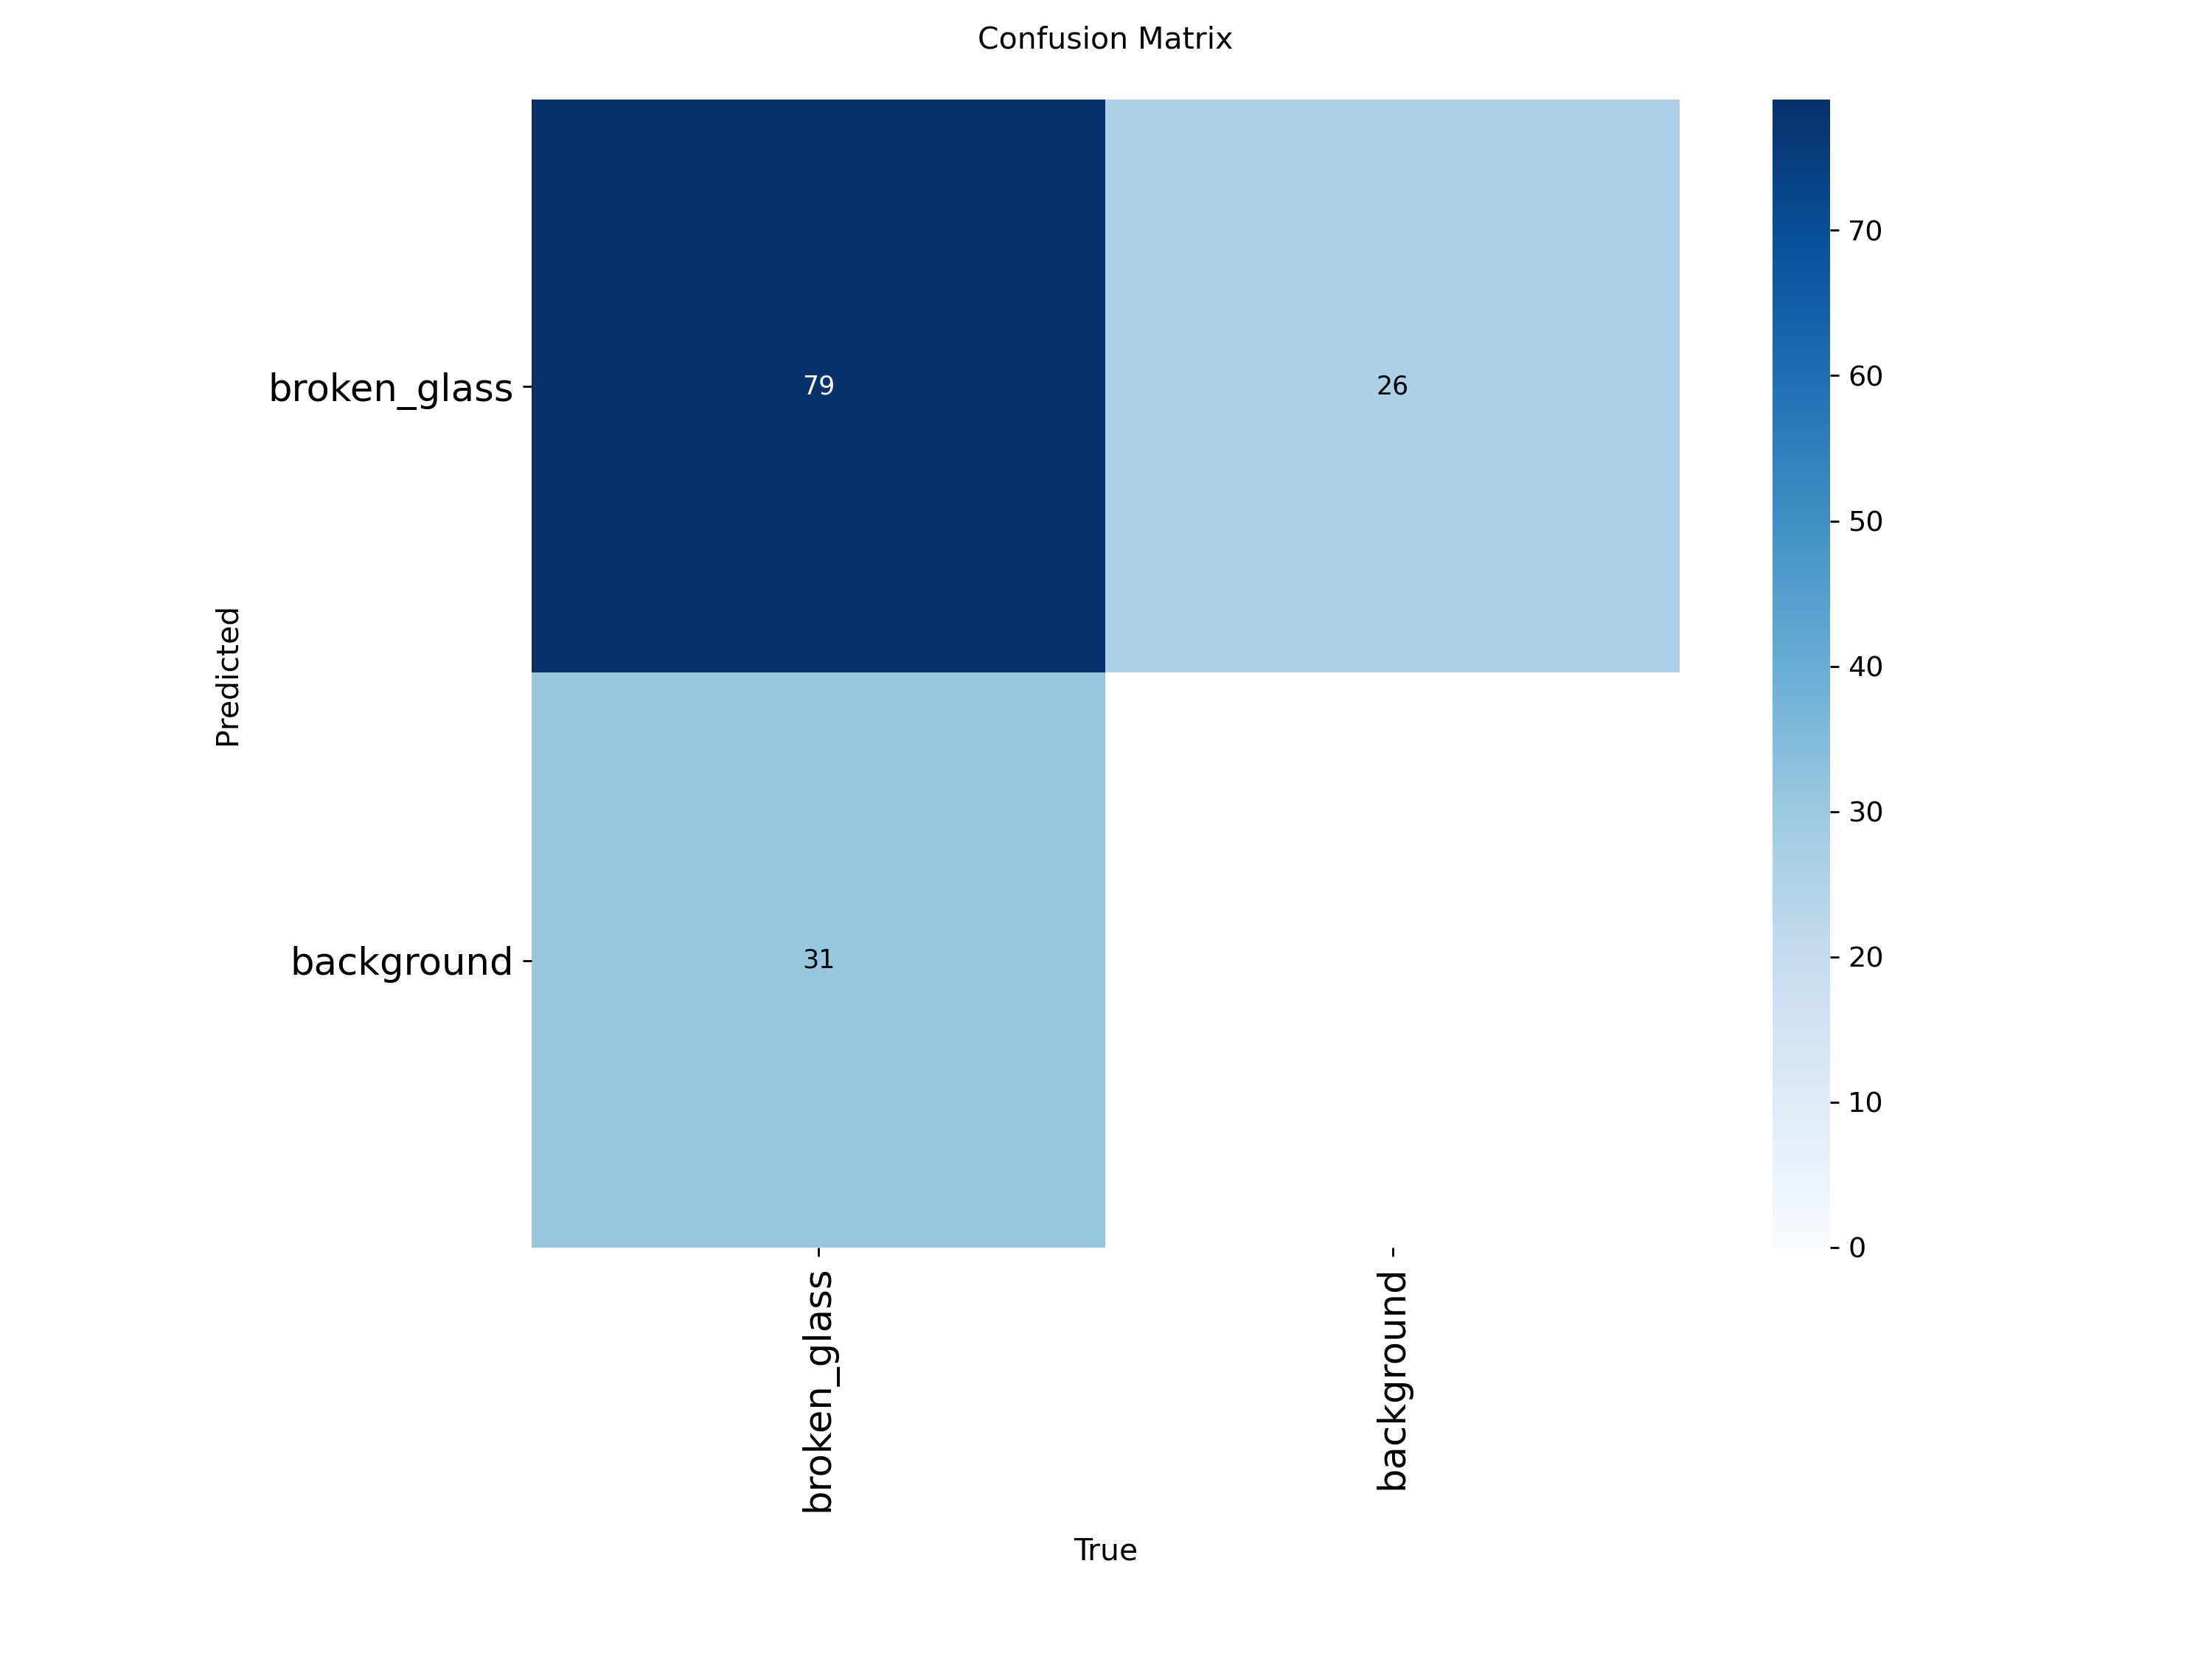


📈 confusion_matrix_normalized.png


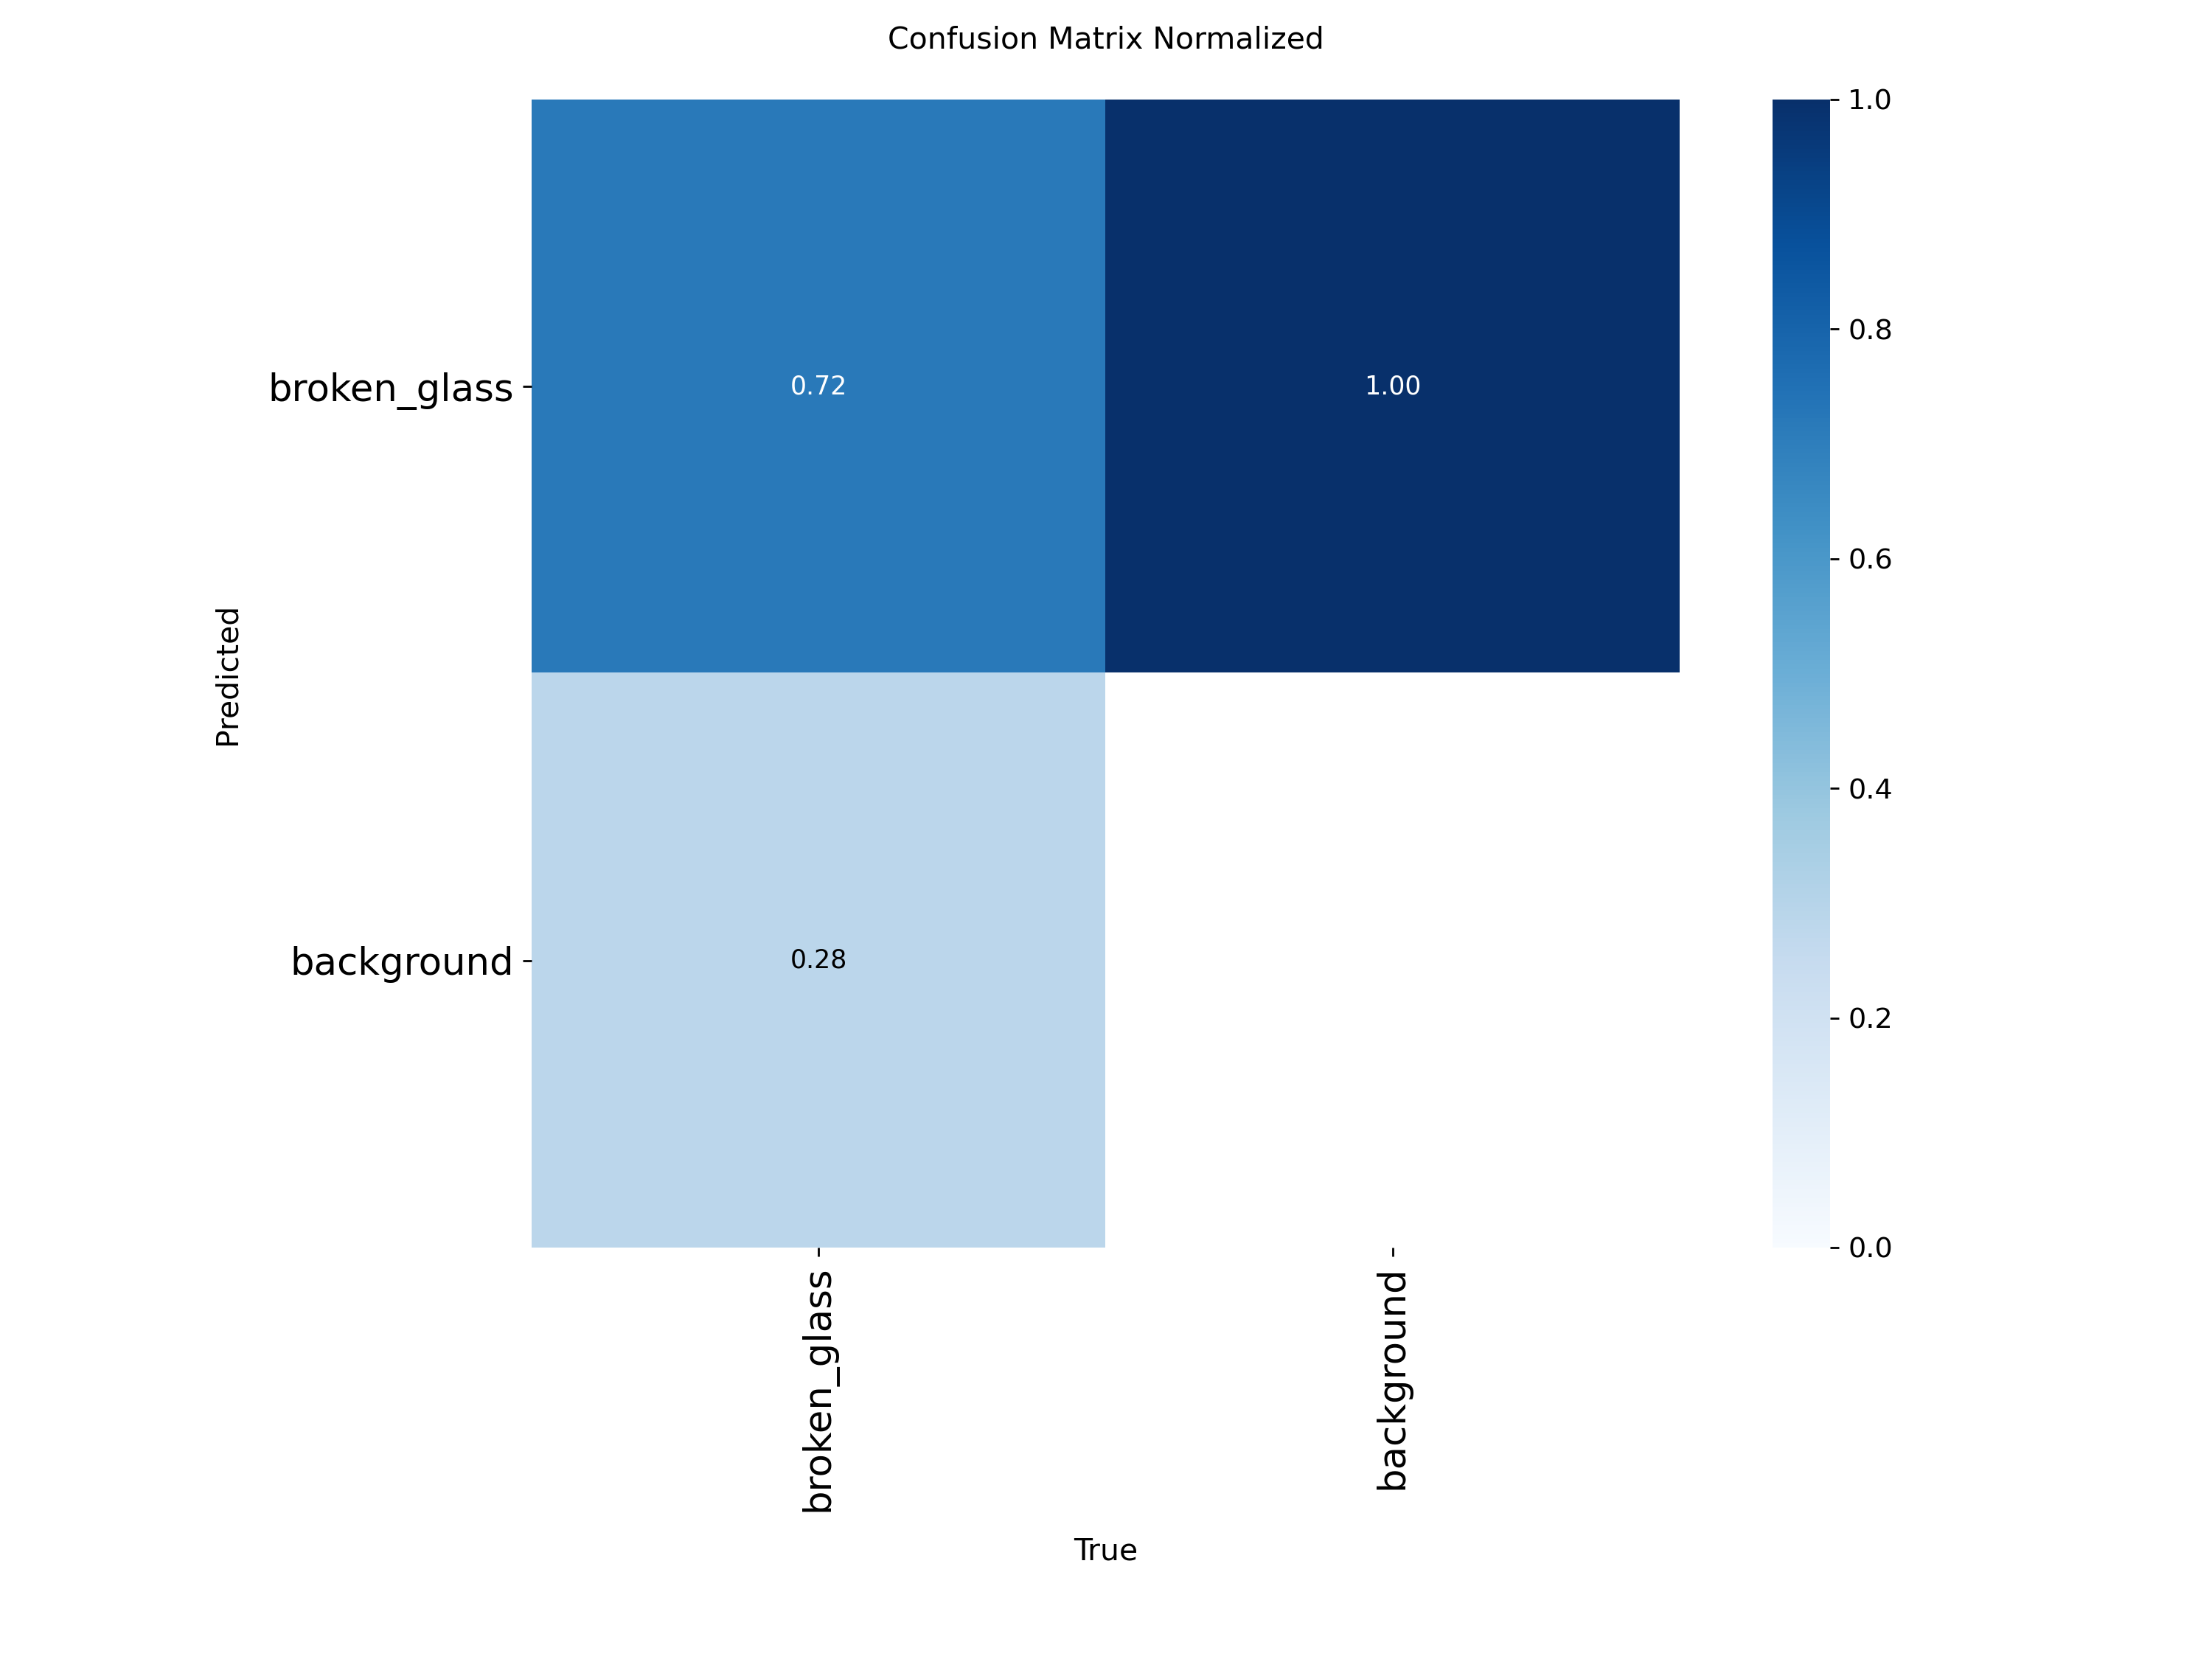

In [7]:
from IPython.display import Image as IPImage, display

plots_dir = os.path.join(RUNS_DIR, 'eval_no_clahe')

for plot in ['confusion_matrix.png', 'confusion_matrix_normalized.png',
             'PR_curve.png', 'F1_curve.png', 'P_curve.png', 'R_curve.png']:
    path = os.path.join(plots_dir, plot)
    if os.path.exists(path):
        print(f'\n📈 {plot}')
        display(IPImage(path, width=750))

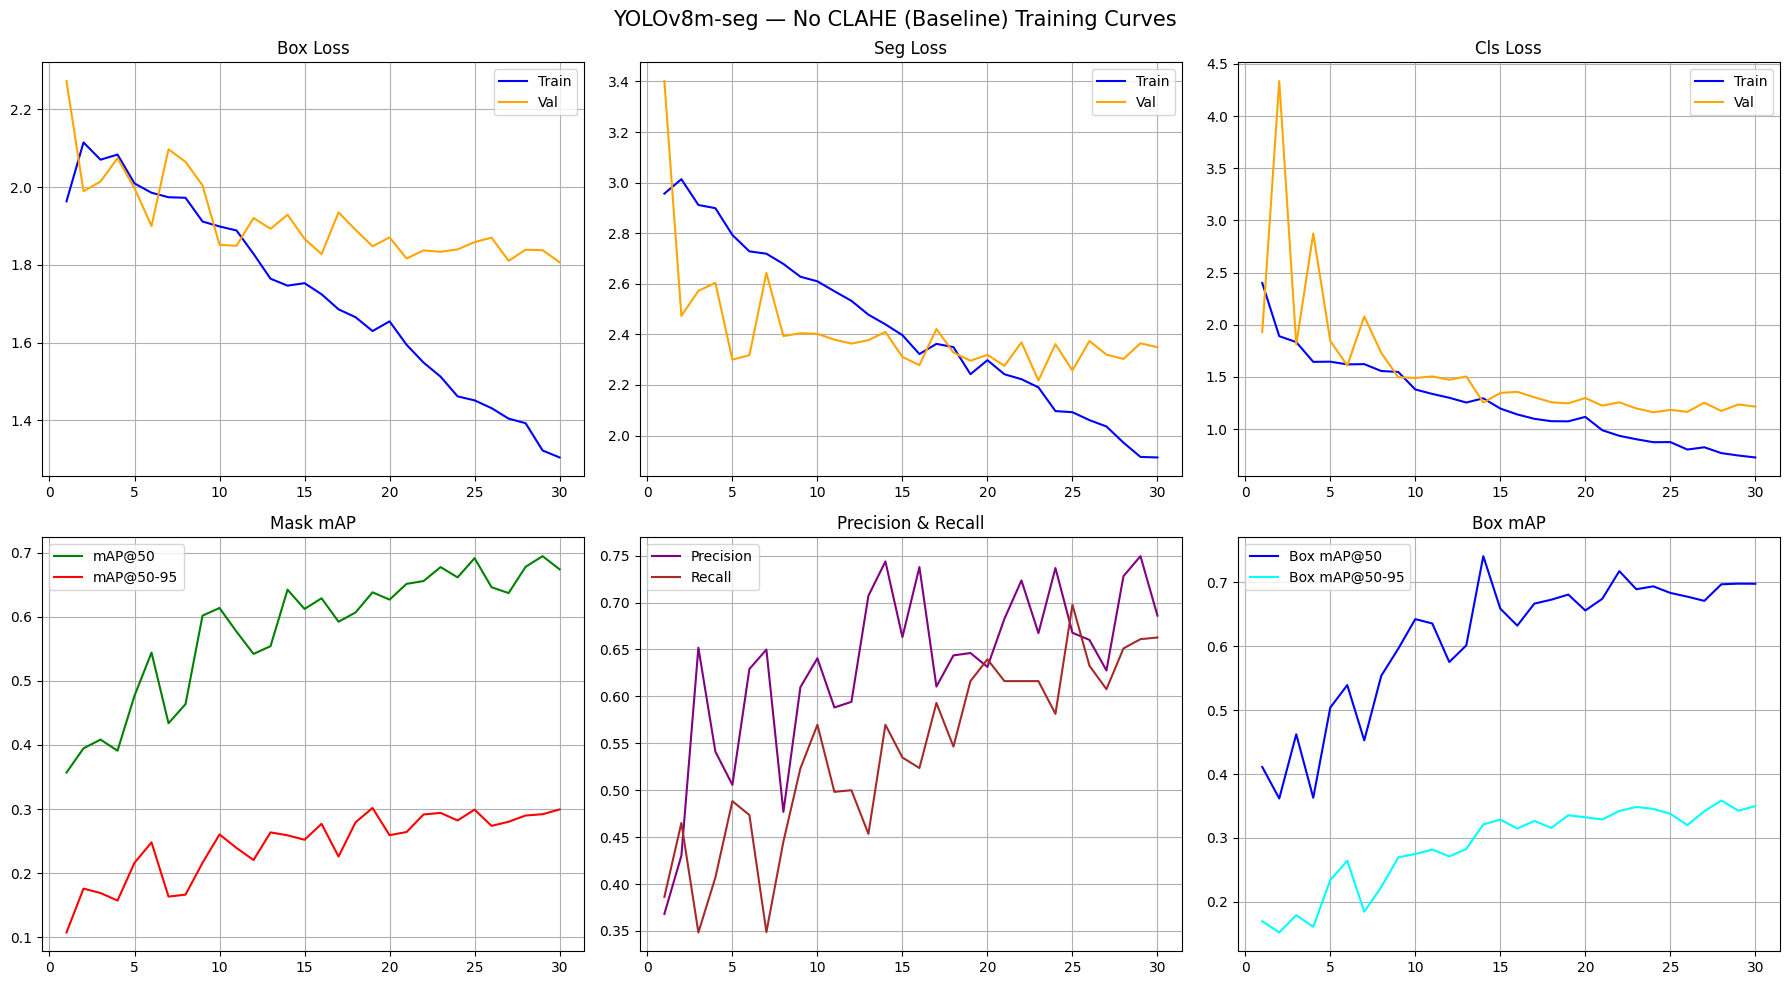

✅ Saved: /content/drive/MyDrive/GlassDetection_Official/runs/training_curves_no_clahe.png


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

csv_path = os.path.join(RUNS_DIR, RUN_NAME, 'results.csv')
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('YOLOv8m-seg — No CLAHE (Baseline) Training Curves', fontsize=15)

axes[0,0].plot(df['epoch'], df['train/box_loss'], label='Train', color='blue')
axes[0,0].plot(df['epoch'], df['val/box_loss'],   label='Val',   color='orange')
axes[0,0].set_title('Box Loss'); axes[0,0].legend(); axes[0,0].grid(True)

axes[0,1].plot(df['epoch'], df['train/seg_loss'], label='Train', color='blue')
axes[0,1].plot(df['epoch'], df['val/seg_loss'],   label='Val',   color='orange')
axes[0,1].set_title('Seg Loss'); axes[0,1].legend(); axes[0,1].grid(True)

axes[0,2].plot(df['epoch'], df['train/cls_loss'], label='Train', color='blue')
axes[0,2].plot(df['epoch'], df['val/cls_loss'],   label='Val',   color='orange')
axes[0,2].set_title('Cls Loss'); axes[0,2].legend(); axes[0,2].grid(True)

axes[1,0].plot(df['epoch'], df['metrics/mAP50(M)'],    label='mAP@50',    color='green')
axes[1,0].plot(df['epoch'], df['metrics/mAP50-95(M)'], label='mAP@50-95', color='red')
axes[1,0].set_title('Mask mAP'); axes[1,0].legend(); axes[1,0].grid(True)

axes[1,1].plot(df['epoch'], df['metrics/precision(M)'], label='Precision', color='purple')
axes[1,1].plot(df['epoch'], df['metrics/recall(M)'],    label='Recall',    color='brown')
axes[1,1].set_title('Precision & Recall'); axes[1,1].legend(); axes[1,1].grid(True)

axes[1,2].plot(df['epoch'], df['metrics/mAP50(B)'],    label='Box mAP@50',    color='blue')
axes[1,2].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='Box mAP@50-95', color='cyan')
axes[1,2].set_title('Box mAP'); axes[1,2].legend(); axes[1,2].grid(True)

plt.tight_layout()
save_path = os.path.join(RUNS_DIR, 'training_curves_no_clahe.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {save_path}')

In [9]:
import cv2
import numpy as np
import os
import shutil
from tqdm import tqdm

BASE     = '/content/drive/MyDrive/GlassDetection_Official/datasets/Vacuum-Hazard-Detection-v1-2'
CLAHE_BASE = '/content/drive/MyDrive/GlassDetection_Official/datasets/Vacuum-Hazard-Detection-v1-2-CLAHE'

def apply_clahe(img_bgr):
    """Apply CLAHE to L channel of LAB colorspace"""
    lab   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_eq  = clahe.apply(l)
    lab_eq = cv2.merge([l_eq, a, b])
    return cv2.cvtColor(lab_eq, cv2.COLOR_LAB2BGR)

# Process all splits
for split in ['train', 'valid', 'test']:
    src_img_dir = os.path.join(BASE,       split, 'images')
    dst_img_dir = os.path.join(CLAHE_BASE, split, 'images')
    src_lbl_dir = os.path.join(BASE,       split, 'labels')
    dst_lbl_dir = os.path.join(CLAHE_BASE, split, 'labels')

    os.makedirs(dst_img_dir, exist_ok=True)
    os.makedirs(dst_lbl_dir, exist_ok=True)

    # Apply CLAHE to every image
    img_files = [f for f in os.listdir(src_img_dir)
                 if f.endswith(('.jpg', '.jpeg', '.png'))]

    print(f'\nProcessing {split} — {len(img_files)} images...')

    for fname in tqdm(img_files):
        src_path = os.path.join(src_img_dir, fname)
        dst_path = os.path.join(dst_img_dir, fname)
        img      = cv2.imread(src_path)
        if img is None:
            continue
        img_clahe = apply_clahe(img)
        cv2.imwrite(dst_path, img_clahe)

    # Copy labels unchanged (same annotations, only images change)
    for lbl_file in os.listdir(src_lbl_dir):
        if lbl_file.endswith('.txt'):
            shutil.copy(
                os.path.join(src_lbl_dir, lbl_file),
                os.path.join(dst_lbl_dir, lbl_file)
            )

    print(f'✅ {split} done')

print('\n✅ CLAHE dataset created!')
print(f'Location: {CLAHE_BASE}')


Processing train — 3540 images...


100%|██████████| 3540/3540 [03:24<00:00, 17.27it/s]


✅ train done

Processing valid — 306 images...


100%|██████████| 306/306 [00:16<00:00, 18.19it/s]


✅ valid done

Processing test — 390 images...


100%|██████████| 390/390 [00:14<00:00, 27.10it/s]


✅ test done

✅ CLAHE dataset created!
Location: /content/drive/MyDrive/GlassDetection_Official/datasets/Vacuum-Hazard-Detection-v1-2-CLAHE


In [10]:
#fix one new one
# Step 2.2 — Create data.yaml for CLAHE Dataset
import yaml

clahe_yaml_path = os.path.join(CLAHE_BASE, 'data.yaml')

# --- FIX: Set nc to 1 and remove the '0' class label ---
clahe_data = {
    'train' : os.path.join(CLAHE_BASE, 'train/images'),
    'val'   : os.path.join(CLAHE_BASE, 'valid/images'),
    'test'  : os.path.join(CLAHE_BASE, 'test/images'),
    'nc'    : 1,
    'names' : ['broken_glass']
}

with open(clahe_yaml_path, 'w') as f:
    yaml.dump(clahe_data, f)

print('✅ CLAHE data.yaml created with 1 class')

✅ CLAHE data.yaml created with 1 class


In [ ]:
from ultralytics import YOLO

model_clahe = YOLO('yolov8m-seg.pt')

results_clahe = model_clahe.train(
    data         = clahe_yaml_path,
    epochs       = 30,
    imgsz        = 640,
    batch        = 16,
    patience     = 20,
    optimizer    = 'AdamW',
    lr0          = 0.001,
    weight_decay = 0.0005,
    augment      = False,
    project      = RUNS_DIR,
    name         = 'glass_seg_clahe_30',
    save         = True,
    save_period  = 10,
    device       = 0,
    workers      = 2,
    plots        = True,
    verbose      = True
)

print('✅ CLAHE Training Complete!')

Ultralytics 8.4.82 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/GlassDetection_Official/datasets/Vacuum-Hazard-Detection-v1-2-CLAHE/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=glass_seg_clahe_30, nbs=

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
print('✅ Drive mounted')